In [ ]:
import pandas as pd
from geopy.distance import geodesic # geodesic은 사용하지 않지만, 원래 코드에 있어 유지합니다.
from sklearn.neighbors import BallTree
import numpy as np

# 1. 역사 데이터 로드 (지상역 위주로 선별 필요)
# UnicodeDecodeError 해결을 위해 encoding='euc-kr' 추가
station_df = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/서울시 역사마스터 정보.csv', encoding='euc-kr')

# 2. S-DoT 위치 데이터 로드
sdot_loc_df = pd.read_excel('/content/drive/MyDrive/SSAFY/BDC/서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx')

# BallTree를 사용하기 위해 위도/경도를 라디안으로 변환
sdot_coords_rad = np.deg2rad(sdot_loc_df[['위도', '경도']].values)
station_coords_rad = np.deg2rad(station_df[['위도', '경도']].values)

# S-DoT 센서 위치로 BallTree 구축 (Haversine 거리 측정 사용)
# Haversine 거리는 (위도, 경도)를 라디안 단위로 예상합니다.
tree = BallTree(sdot_coords_rad, metric='haversine')

# 검색 반경 (미터)
radius_m = 500
# 지구 평균 반경 (미터)
earth_radius_m = 6371000
# BallTree 쿼리를 위한 반경을 라디안으로 변환
radius_rad = radius_m / earth_radius_m

# 철도 주변 센서 SN 리스트 확보
rail_sensor_sns = []

# 모든 역사에 대해 주변 센서 찾기 및 rail_sensor_sns 채우기
for i, station_row in station_df.iterrows():
    station_lat_rad = station_coords_rad[i, 0]
    station_lon_rad = station_coords_rad[i, 1]

    # BallTree를 사용하여 반경 내 센서 쿼리
    # query_radius는 인접한 센서의 인덱스 배열 목록을 반환합니다.
    indices_list = tree.query_radius([[station_lat_rad, station_lon_rad]], r=radius_rad)

    # 인접한 센서의 인덱스 추출
    nearby_sensor_indices = indices_list[0]

    # 인접 센서의 시리얼 번호 가져오기 (공백 제거 추가)
    nearby_sns_for_station = sdot_loc_df.iloc[nearby_sensor_indices]['모델 시리얼(*)'].astype(str).str.strip().tolist()

    rail_sensor_sns.extend(nearby_sns_for_station)

# 중복 제거
rail_sensor_sns = list(set(rail_sensor_sns))

# 기존의 get_nearby_sensors 함수는 더 이상 필요하지 않습니다.
# def get_nearby_sensors(station_lat, station_lon, sdot_df, radius_m=500):
#     nearby_sns = []
#     for idx, row in sdot_df.iterrows():
#         dist = geodesic((station_lat, station_lon), (row['위도'], row['경도'])).meters
#         if dist <= radius_m:
#             nearby_sns.append(row['모델 시리얼(*)'])
#     return nearby_sns


In [ ]:
import pandas as pd

# CSV 파일의 첫 몇 줄만 읽어서 컬럼 이름을 확인합니다.
# 파일 전체를 로드하는 것은 시간이 오래 걸릴 수 있으므로, nrows=50000과 같은 옵션을 사용하여 일부만 로드합니다.
# 실제 파일을 보고 어떤 컬럼이 '시리얼'에 해당하는지 확인해주세요。

try:
    temp_df = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/S-DoT_NATURE_2026.03.30-04.05.csv', nrows=5, encoding='euc-kr')
    # print("CSV 파일의 컬럼 목록:")
    # for col in temp_df.columns:
    #     print(f"- {col}")
    print("\n--- 첫 5개 행 데이터 미리보기 ---")
    display(temp_df)
except Exception as e:
    print(f"CSV 파일을 읽는 중 오류 발생: {e}")
    print("파일 경로 및 인코딩을 확인해주세요.")

print("위 출력에서 실제 센서의 시리얼 번호가 포함된 컬럼 이름을 확인해주세요.")
print("확인한 후, `czkeEbb3WJPF` 셀로 이동하여 `target_columns_korean` 리스트의 '시리얼' 대신 해당 컬럼 이름으로 수정해야 합니다.")


--- 첫 5개 행 데이터 미리보기 ---


모델번호  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        16.1   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  15.2   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     14.9   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         14.7   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2     9.3   

                                                                                         시리얼  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        15.9   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  14.8   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     14.6   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         14.6   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2     9.2   

                                                                                        측정시간  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        15.5   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  14.6   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     14.4   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         14.4   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2     9.0   

                                                                                          지역  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        28.0   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  31.0   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     39.0   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         35.0   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2    47.0   

                                                                                         자치구  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        27.0   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  30.0   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     39.0   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         34.0   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2    44.0   

                                                                                         행정동  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong        26.0   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong  26.0   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong     38.0   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong         32.0   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2    41.0   

                                                                                        온도 최대(℃)  \
SDOT001 OC3CL200014 2026-03-30_00:07:00 main_street Jung-gu          Myeong-dong             NaN   
        OC3CL200020 2026-03-30_00:07:00 main_street Gangnam-gu       Yeoksam1(il)-dong       NaN   
        OC3CL200016 2026-03-30_00:07:00 main_street Gangnam-gu       Apgujeong-dong          NaN   
        OC3CL200021 2026-03-30_00:07:00 main_street Gangnam-gu       Sinsa-dong              NaN   
        OC3CL200010 2026-03-30_00:07:00 parks       Seoul_Grand_Park meeting_bridge2         NaN   

                         

위 출력에서 실제 센서의 시리얼 번호가 포함된 컬럼 이름을 확인해주세요.
확인한 후, `czkeEbb3WJPF` 셀로 이동하여 `target_columns_korean` 리스트의 '시리얼' 대신 해당 컬럼 이름으로 수정해야 합니다.


In [ ]:
import pandas as pd

# 분석에 필요한 컬럼만 정의 (2번 명세서 참고)
# 실제 CSV 파일의 컬럼 이름에 맞게 수정
# 'level_1'이 센서 시리얼 번호를, 'level_2'가 측정시간을 포함하고 있습니다.
target_columns_korean = ['level_1', 'level_2', '소음 평균(dB)', '소음 최대(dB)', '진동(x) 평균(mm/s)', '진동(y) 평균(mm/s)', '진동(z) 평균(mm/s)']

# 디버깅: rail_sensor_sns 샘플 출력 (PqxaWkUERJFR에서 공백 제거 후)
print(f"\nSample of rail_sensor_sns (first 5, after stripping in previous cell): {rail_sensor_sns[:5]}")
print(f"Number of unique serials in rail_sensor_sns: {len(rail_sensor_sns)}")

filtered_data = []

# CSV 파일 읽기 (모든 컬럼을 읽어 인덱스 처리 후 필터링)
chunks_iterator = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/S-DoT_NATURE_2026.03.30-04.05.csv', chunksize=50000, encoding='euc-kr')

for i, chunk in enumerate(chunks_iterator):
    # 멀티인덱스를 컬럼으로 변환합니다. 이때 시리얼 번호는 'level_1' 컬럼으로 생성됩니다.
    chunk = chunk.reset_index()

    # 디버깅: 첫 번째 청크의 컬럼 구조 확인 (reset_index 후)
    if i == 0:
        print(f"\n--- First chunk raw structure (after reset_index) ---")
        print(f"Chunk columns: {chunk.columns.tolist()}")
        print(f"Chunk head (all columns):\n{chunk.head().to_string()}")
        print("\n--- IMPORTANT: From the output above, confirm 'level_1' contains actual sensor serial numbers (e.g., 'OC3CL200014').")
        print("  - After confirmation, you MUST update `target_columns_korean` list in this cell, replacing the first item with 'level_1' if that's where serials are.")

    # 현재 target_columns_korean에서 시리얼 번호 컬럼으로 지정된 이름을 사용합니다.
    try:
        current_chunk_serial_col_name = target_columns_korean[0] # 'level_1'로 지정

        if current_chunk_serial_col_name not in chunk.columns:
            print(f"Error: Serial number column '{current_chunk_serial_col_name}' not found in chunk columns {chunk.columns.tolist()}. Please update `target_columns_korean` to the correct serial column (likely 'level_1').")
            continue

        # 시리얼 컬럼의 데이터 타입을 문자열로 변환 후 공백 제거
        chunk[current_chunk_serial_col_name] = chunk[current_chunk_serial_col_name].astype(str).str.strip()

        # 추가 디버깅: 첫 번째 청크에서 rail_sensor_sns와의 교집합 확인
        if i == 0:
            chunk_sns = set(chunk[current_chunk_serial_col_name].unique())
            overlap_in_chunk = chunk_sns.intersection(rail_sensor_sns)
            print(f"\nDEBUG: Unique SNs in first chunk ('{current_chunk_serial_col_name}'): {len(chunk_sns)}")
            print(f"DEBUG: Overlapping SNs in first chunk with rail_sensor_sns: {len(overlap_in_chunk)}")
            if overlap_in_chunk:
                print(f"DEBUG: Sample of overlapping SNs in first chunk: {list(overlap_in_chunk)[:5]}")

        # 철도 주변 센서 데이터만 필터링
        temp = chunk[chunk[current_chunk_serial_col_name].isin(rail_sensor_sns)]

        # 필요한 컬럼만 선택
        # target_columns_korean에 'level_1'과 'level_2'가 포함되어 있어야 합니다.
        selected_columns = [col for col in target_columns_korean if col in chunk.columns]
        temp = temp[selected_columns]

        filtered_data.append(temp)
    except Exception as e:
        print(f"Error processing chunk {i}: {e}")
        continue

# 하나로 합치기
sdot_final = pd.concat(filtered_data)

# 디버깅: sdot_final의 최종 크기 확인
print(f"\nFinal sdot_final DataFrame shape: {sdot_final.shape}")
if sdot_final.empty:
    print("sdot_final is empty. No matching data was found.")
else:
    print(f"Sample of sdot_final DataFrame:\n{sdot_final.head()}")

# 컬럼 이름을 영문으로 변경하여 일관성 유지
sdot_final = sdot_final.rename(columns={
    'level_1': 'SERIAL_NO', # 'level_1'을 'SERIAL_NO'로 변경
    'level_2': 'MSRMT_HR', # 'level_2'를 'MSRMT_HR'로 변경
    '소음 평균(dB)': 'AVG_NIS',
    '소음 최대(dB)': 'MAX_NIS',
    '진동(x) 평균(mm/s)': 'AVG_VIBR_XCRD',
    '진동(y) 평균(mm/s)': 'AVG_VIBR_YCRD',
    '진동(z) 평균(mm/s)': 'AVG_VIBR_ZCRD'
})

# 측정 관련 컬럼에 모두 NaN 값이 있는 행 제거
measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']
sdot_final = sdot_final.dropna(subset=measurement_cols, how='all')
print(f"DataFrame shape after dropping rows with all NaN measurements: {sdot_final.shape}")

# 시간 데이터 형변환 및 시간대별 평균 집계 (데이터 크기 추가 축소)
sdot_final['MSRMT_HR'] = pd.to_datetime(sdot_final['MSRMT_HR'], format='%Y-%m-%d_%H:%M:%S')
# MSRMT_HR 컬럼이 이미 존재하므로, 그룹화에 사용할 시간 컬럼에 다른 이름을 부여
sdot_final['hour_of_day'] = sdot_final['MSRMT_HR'].dt.hour
sdot_hourly = sdot_final.groupby(['SERIAL_NO', 'hour_of_day']).mean().reset_index()

# 디버깅: sdot_hourly의 최종 크기 확인
print(f"\nFinal sdot_hourly DataFrame shape: {sdot_hourly.shape}")
if sdot_hourly.empty:
    print("sdot_hourly is empty after aggregation.")
else:
    print(f"Sample of sdot_hourly DataFrame:\n{sdot_hourly.head()}")


Sample of rail_sensor_sns (first 5, after stripping in previous cell): ['V02Q1940955', 'V02Q1940461', 'V02Q1940622', 'V02Q1940648', 'V02Q1940145']
Number of unique serials in rail_sensor_sns: 696

--- First chunk raw structure (after reset_index) ---
Chunk columns: ['level_0', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5', '모델번호', '시리얼', '측정시간', '지역', '자치구', '행정동', '온도 최대(℃)', '온도 평균(℃)', '온도 최소(℃)', '습도 최대(%)', '습도 평균(%)', '습도 최소(%)', '풍속 최대(m/s)', '풍속 평균(m/s)', '풍속 최소(m/s)', '풍향 최대(m/s)', '풍향 평균(m/s)', '풍향 최소(m/s)', '조도 최대(lux)', '조도 평균(lux)', '조도 최소(lux)', '자외선 최대(UV)', '자외선 평균(UV)', '자외선 최대(UV).1', '소음 최대(dB)', '소음 평균(dB)', '소음 최소(dB)', '진동(x) 최대(mm/s)', '진동(x) 평균(mm/s)', '진동(x) 최소(mm/s)', '진동(y) 최대(mm/s)', '진동(y) 평균(mm/s)', '진동(y) 최소(mm/s)', '진동(z) 최대(mm/s)', '진동(z) 평균(mm/s)', '진동(z) 최소(mm/s)', '흑구온도 최대(℃)', '흑구온도 평균(℃)', '흑구온도 최소(℃)', '이산화질소 최대(ppm)', '이산화질소 평균(ppm)', '이산화질소 최소(ppm)', '일산화탄소 최대(ppm)', '일산화탄소 평균(ppm)', '일산화탄소 최소(ppm)', '이산화황 최대(ppm)', '이산화황 평균(ppm)', '이산화

### `rail_sensor_sns`와 `S-DoT_NATURE` 파일의 시리얼 번호 교집합 확인
이전 셀에서 `sdot_final`이 비어있는 원인을 파악하기 위해, `rail_sensor_sns` 리스트와 `S-DoT_NATURE` 데이터 파일의 실제 시리얼 번호(`level_1`) 간에 공통된 값이 있는지 확인합니다. 일치하는 값이 없다면, 필터링 결과가 비어있는 것이 정상입니다.

In [ ]:
import pandas as pd

# S-DoT_NATURE 파일에서 'level_1' 컬럼의 고유한 시리얼 번호를 추출
# 효율성을 위해 첫 번째 청크에서만 시리얼 번호를 샘플링하여 비교합니다.
# 전체 파일을 읽으면 오래 걸릴 수 있으므로, 대표성을 띠는 일부 데이터만 확인합니다.

chunks_iterator = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/S-DoT_NATURE_2026.03.30-04.05.csv', chunksize=50000, encoding='euc-kr')

nature_file_sns = set()
for i, chunk in enumerate(chunks_iterator):
    chunk = chunk.reset_index() # level_1 컬럼을 만들기 위해 인덱스 리셋
    if 'level_1' in chunk.columns:
        nature_file_sns.update(chunk['level_1'].astype(str).str.strip().tolist())
    # 첫 번째 청크만 확인 후 break (데이터 규모에 따라 조정 가능)
    if i == 0:
        break

# rail_sensor_sns와 nature_file_sns 간의 교집합 확인
common_sns = set(rail_sensor_sns).intersection(nature_file_sns)

print(f"\nTotal unique SNs in rail_sensor_sns: {len(rail_sensor_sns)}")
print(f"Total unique SNs sampled from S-DoT_NATURE file ('level_1' column): {len(nature_file_sns)}")
print(f"Number of common SNs between rail_sensor_sns and S-DoT_NATURE file: {len(common_sns)}")

if common_sns:
    print(f"Sample of common SNs: {list(common_sns)[:10]}")
else:
    print("No common serial numbers found between rail_sensor_sns and S-DoT_NATURE file.")
    print("This is likely the reason why sdot_final is empty.")
    print("Please verify if the '모델 시리얼(*)' column in '서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx' file and the 'level_1' column in 'S-DoT_NATURE_2026.03.30-04.05.csv' file actually refer to the same set of sensors.")


Total unique SNs in rail_sensor_sns: 696
Total unique SNs sampled from S-DoT_NATURE file ('level_1' column): 905
Number of common SNs between rail_sensor_sns and S-DoT_NATURE file: 533
Sample of common SNs: ['V02Q1940955', 'V02Q1940622', 'V02Q1940648', 'V02Q1940145', 'V02Q1940782', 'V02Q1940465', 'V02Q1940218', 'V02Q1940080', 'OC3CL200165', 'V02Q1940273']


In [ ]:
sdot_hourly.to_csv('/content/drive/MyDrive/SSAFY/BDC/sdot_hourly_preprocessed.csv', index=False)

### 저장된 `sdot_hourly_preprocessed.csv` 파일 불러오기 및 확인

In [ ]:
sdot_hourly_loaded = pd.read_csv('/content/drive/MyDrive/SSAFY/BDC/sdot_hourly_preprocessed.csv')

print("\n--- Loaded sdot_hourly_preprocessed.csv Head ---")
display(sdot_hourly_loaded.head())

print("\n--- Loaded sdot_hourly_preprocessed.csv Info ---")
sdot_hourly_loaded.info()

print("\n--- Loaded sdot_hourly_preprocessed.csv Descriptive Statistics ---")
display(sdot_hourly_loaded.describe())


--- Loaded sdot_hourly_preprocessed.csv Head ---


,SERIAL_NO,hour_of_day,MSRMT_HR,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
0,OC3CL200158,0,2026-04-02 00:07:00,NaN,NaN,NaN,NaN,0.741857
1,OC3CL200158,1,2026-04-02 01:07:00,NaN,NaN,NaN,NaN,0.745143
2,OC3CL200158,2,2026-04-02 02:07:00,NaN,NaN,NaN,NaN,0.741857
3,OC3CL200158,3,2026-04-02 15:07:00,NaN,NaN,NaN,NaN,0.732833
4,OC3CL200158,4,2026-04-02 16:07:00,NaN,NaN,NaN,NaN,0.714667



--- Loaded sdot_hourly_preprocessed.csv Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9811 entries, 0 to 9810
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SERIAL_NO      9811 non-null   object 
 1   hour_of_day    9811 non-null   int64  
 2   MSRMT_HR       9811 non-null   object 
 3   AVG_NIS        9721 non-null   float64
 4   MAX_NIS        9721 non-null   float64
 5   AVG_VIBR_XCRD  9721 non-null   float64
 6   AVG_VIBR_YCRD  0 non-null      float64
 7   AVG_VIBR_ZCRD  786 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 613.3+ KB

--- Loaded sdot_hourly_preprocessed.csv Descriptive Statistics ---


,hour_of_day,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
count,9811.000000,9721.000000,9721.000000,9721.000000,0.0,786.000000
mean,11.499439,0.061872,0.066266,1.016543,NaN,0.523677
std,6.923249,0.039325,0.039409,0.117341,NaN,0.369289
min,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,5.000000,0.028571,0.030000,1.008571,NaN,0.263536
50%,12.000000,0.055714,0.060000,1.030000,NaN,0.494929
75%,17.500000,0.090000,0.091429,1.050000,NaN,0.672821
max,23.000000,0.221429,0.382857,1.135714,NaN,2.000000


### 역사 영향권 내 센서 데이터 집계

각 역사별 영향권 내에 존재하는 S-DoT 센서들의 소음 및 진동 데이터를 평균하여, 역사별 환경 정보를 집계합니다. 이 데이터는 지도에 역사 영향권을 표시할 때 사용될 상세 툴팁 정보로 활용됩니다.

In [15]:
import pandas as pd
import numpy as np

# Assuming tree, radius_m, station_df, sdot_loc_df, sdot_hourly_loaded are available from previous cells

station_aggregated_metrics = []
measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']

for i, station_row in station_df.iterrows(): # Use the existing station_df
    station_lat_rad = station_coords_rad[i, 0] # Use existing station_coords_rad
    station_lon_rad = station_coords_rad[i, 1]

    # Use the existing tree and radius_rad
    indices_list = tree.query_radius([[station_lat_rad, station_lon_rad]], r=radius_rad)
    nearby_sensor_indices = indices_list[0]

    nearby_sns_for_station = sdot_loc_df.iloc[nearby_sensor_indices]['모델 시리얼(*)'].astype(str).str.strip().tolist() # Use existing sdot_loc_df

    if nearby_sns_for_station:
        station_nearby_sensor_data = sdot_hourly_loaded[sdot_hourly_loaded['SERIAL_NO'].isin(nearby_sns_for_station)]

        if not station_nearby_sensor_data.empty:
            avg_metrics = station_nearby_sensor_data[measurement_cols].mean().to_dict()
            station_aggregated_metrics.append({
                '역사_ID': station_row['역사_ID'],
                '역사명': station_row['역사명'],
                '호선': station_row['호선'],
                '위도': station_row['위도'],
                '경도': station_row['경도'],
                'NUM_NEARBY_SENSORS': len(nearby_sns_for_station),
                **avg_metrics
            })
        else:
            station_aggregated_metrics.append({
                '역사_ID': station_row['역사_ID'],
                '역사명': station_row['역사명'],
                '호선': station_row['호선'],
                '위도': station_row['위도'],
                '경도': station_row['경도'],
                'NUM_NEARBY_SENSORS': len(nearby_sns_for_station),
                **{col: np.nan for col in measurement_cols}
            })
    else:
        station_aggregated_metrics.append({
            '역사_ID': station_row['역사_ID'],
            '역사명': station_row['역사명'],
            '호선': station_row['호선'],
            '위도': station_row['위도'],
            '경도': station_row['경도'],
            'NUM_NEARBY_SENSORS': 0,
            **{col: np.nan for col in measurement_cols}
        })

station_plot_df = pd.DataFrame(station_aggregated_metrics)
print("\n--- Station Aggregated Metrics Head ---")
display(station_plot_df.head())
print(f"Shape of station_plot_df: {station_plot_df.shape}")

# Filter out stations with no nearby sensors/data for plotting relevant info
station_plot_df_filtered = station_plot_df.dropna(subset=measurement_cols, how='all')
print(f"Shape of station_plot_df after filtering for valid sensor data: {station_plot_df_filtered.shape}")


--- Station Aggregated Metrics Head ---


,역사_ID,역사명,호선,위도,경도,NUM_NEARBY_SENSORS,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569,0,NaN,NaN,NaN,NaN,NaN
1,9009,구성,수도권 광역급행철도,37.29913,127.10389,0,NaN,NaN,NaN,NaN,NaN
2,9008,성남,수도권 광역급행철도,37.39467,127.12058,0,NaN,NaN,NaN,NaN,NaN
3,9007,수서,수도권 광역급행철도,37.48637,127.10161,1,0.025774,0.030238,1.050833,NaN,NaN
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324,0,NaN,NaN,NaN,NaN,NaN


Shape of station_plot_df: (783, 11)
Shape of station_plot_df after filtering for valid sensor data: (308, 11)


### 지도 시각화 업데이트

- S-DoT 센서(`CircleMarker`): 초기에는 더 작은 고정된 크기(반경 3)의 원으로 표시됩니다.
- 역사 영향권(`folium.Circle`): 마우스 오버 시 역사명, 호선, 영향권 반경, 인근 센서 수, 그리고 집계된 평균 소음 및 진동(Z축) 수준을 포함하는 상세 툴팁이 표시됩니다.

In [ ]:
print("\n--- sdot_hourly DataFrame Descriptive Statistics ---")
if not sdot_hourly.empty:
    display(sdot_hourly.describe())
else:
    print("sdot_hourly DataFrame is empty. No statistics to display.")


--- sdot_hourly DataFrame Descriptive Statistics ---


,hour_of_day,MSRMT_HR,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
count,9811.000000,9811,9721.000000,9721.000000,9721.000000,0.0,786.000000
mean,11.499439,2026-04-02 11:10:10.659463424,0.061872,0.066266,1.016543,NaN,0.523677
min,0.000000,2026-03-30 02:07:00,0.000000,0.000000,0.000000,NaN,0.000000
25%,5.000000,2026-04-02 05:07:00,0.028571,0.030000,1.008571,NaN,0.263536
50%,12.000000,2026-04-02 11:07:00,0.055714,0.060000,1.030000,NaN,0.494929
75%,17.500000,2026-04-02 18:07:00,0.090000,0.091429,1.050000,NaN,0.672821
max,23.000000,2026-04-05 14:07:00,0.221429,0.382857,1.135714,NaN,2.000000
std,6.923249,NaN,0.039325,0.039409,0.117341,NaN,0.369289


In [ ]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf
# 세션 다시 시작

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

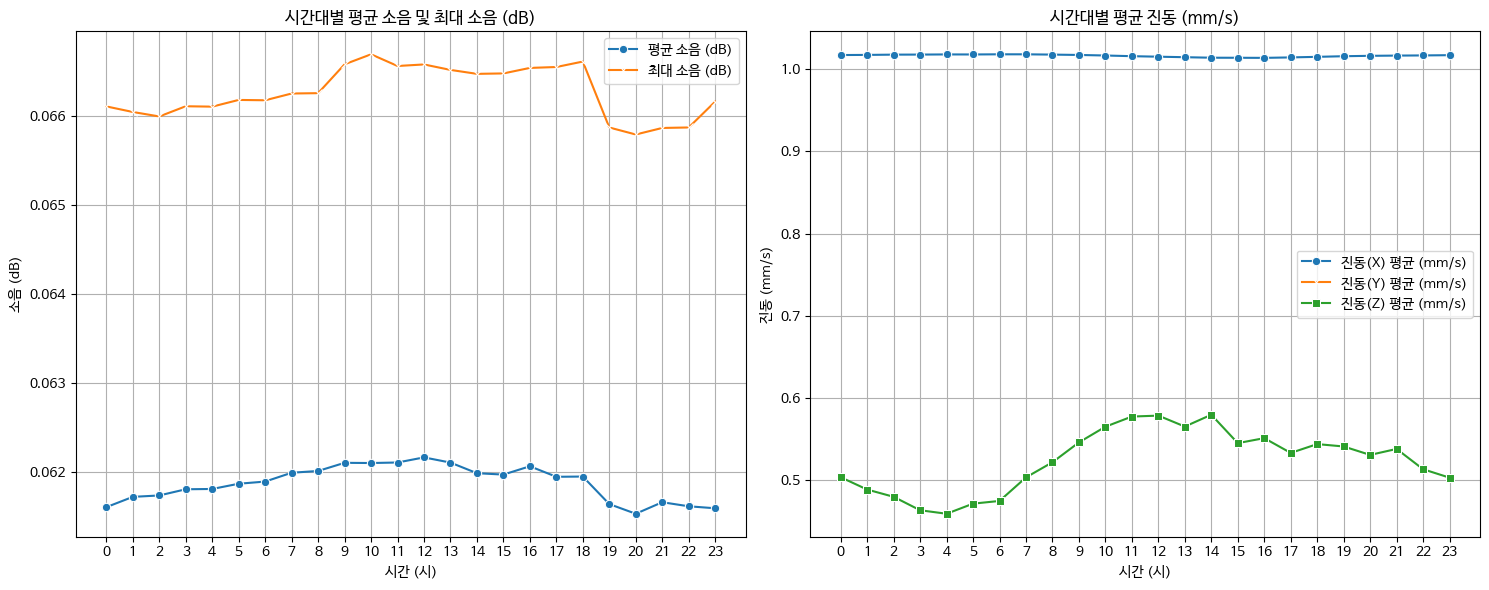

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# 시간대별 평균 소음 및 진동 계산
hourly_avg_data = sdot_hourly.groupby('hour_of_day')[['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']].mean().reset_index()

# 플롯 설정
plt.figure(figsize=(15, 6))

# 소음 데이터 플롯
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째 플롯
sns.lineplot(x='hour_of_day', y='AVG_NIS', data=hourly_avg_data, label='평균 소음 (dB)', marker='o')
sns.lineplot(x='hour_of_day', y='MAX_NIS', data=hourly_avg_data, label='최대 소음 (dB)', marker='x')
plt.title('시간대별 평균 소음 및 최대 소음 (dB)')
plt.xlabel('시간 (시)')
plt.ylabel('소음 (dB)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

# 진동 데이터 플롯
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째 플롯
sns.lineplot(x='hour_of_day', y='AVG_VIBR_XCRD', data=hourly_avg_data, label='진동(X) 평균 (mm/s)', marker='o')
sns.lineplot(x='hour_of_day', y='AVG_VIBR_YCRD', data=hourly_avg_data, label='진동(Y) 평균 (mm/s)', marker='x')
sns.lineplot(x='hour_of_day', y='AVG_VIBR_ZCRD', data=hourly_avg_data, label='진동(Z) 평균 (mm/s)', marker='s')
plt.title('시간대별 평균 진동 (mm/s)')
plt.xlabel('시간 (시)')
plt.ylabel('진동 (mm/s)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [28]:
import pandas as pd
import folium
import branca.colormap as cm
import numpy as np
import json

# 1. 전처리된 데이터 로드 (각 센서별 평균 계산)
measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']
sdot_sensor_avg_metrics = sdot_hourly_loaded.groupby('SERIAL_NO')[measurement_cols].mean().reset_index()

# S-DoT 위치 데이터 병합 ('주소' 컬럼 추가) 및 '자치구' 정보 포함
sdot_loc_df_renamed = sdot_loc_df.rename(columns={'모델 시리얼(*)': 'SERIAL_NO'})

# '자치구' 컬럼이 없는 경우 '주소' 컬럼에서 추출
if '자치구' not in sdot_loc_df_renamed.columns:
    # '주소' 컬럼에서 '자치구' 정보를 추출합니다 (예: '서울특별시 종로구' -> '종로구')
    # 정규표현식을 사용하여 '서울특별시 ' 뒤에 오는 '구'로 끝나는 문자열을 찾습니다.
    sdot_loc_df_renamed['자치구'] = sdot_loc_df_renamed['주소'].astype(str).str.extract(r'서울특별시\s*([^\s]+구)')[0]
    # 추출되지 않은 경우 (예: 서울시가 아닌 주소 또는 형식 불일치) NaN 처리
    sdot_loc_df_renamed['자치구'] = sdot_loc_df_renamed['자치구'].fillna(pd.NA) # FutureWarning 해결: inplace=True 제거

sdot_map_data = pd.merge(sdot_sensor_avg_metrics, sdot_loc_df_renamed[['SERIAL_NO', '위도', '경도', '주소', '자치구']], on='SERIAL_NO', how='inner')

# --- 서울시 데이터만 필터링 ---
sdot_map_data = sdot_map_data[sdot_map_data['주소'].astype(str).str.contains('서울')]

print("\n--- S-DoT Map Data Head (Seoul Only) ---")
display(sdot_map_data.head())
print(f"Number of sensors to plot (Seoul): {len(sdot_map_data)}")

# --- [새로운 요구사항] 행정동별 소음/진동 데이터 집계 ---
# 현재 sdot_map_data에 '행정동' 컬럼이 없으므로, '자치구' 기준으로 집계합니다.
# '행정동' 데이터가 있다면 district_data.groupby('행정동')으로 변경해야 합니다.
# GeoJSON 파일이 '행정동' 단위이므로, '자치구' 데이터를 '행정동'에 매핑하는 방식으로 진행됩니다.
# 이 과정에서 같은 '자치구' 내 모든 '행정동'은 동일한 소음 값으로 표시될 수 있습니다.

district_data_for_choropleth = sdot_map_data.dropna(subset=['자치구']).copy()
district_avg_metrics_for_choropleth = district_data_for_choropleth.groupby('자치구')[['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']].mean().reset_index()

# --- 다크 테마 지도 시작점 설정 ---
m = folium.Map(location=[37.55, 126.97], zoom_start=12, tiles='cartodbdark_matter')

# --- S-DoT 센서 컬러맵(Legend) 생성 ---
min_noise_sensor = sdot_map_data['AVG_NIS'].min()
max_noise_sensor = sdot_map_data['AVG_NIS'].max()

sensor_colormap = cm.LinearColormap(
    colors=['#00FF00', '#FFFF00', '#FFA500', '#FF0000', '#800080'],
    vmin=min_noise_sensor,
    vmax=max_noise_sensor,
    caption='S-DoT 센서 평균 소음 수준 (dB)'
)
# 캡션 글자색을 흰색으로 변경하기 위한 스타일 추가
sensor_colormap.caption = f'<span style="color:white;">{sensor_colormap.caption}</span>'
m.add_child(sensor_colormap)

# --- 행정동 코로플레스 지도 레이어 추가 ---
geoj_path_admin = '/content/drive/MyDrive/SSAFY/BDC/서울_행정동_경계_2017.geojson'

try:
    with open(geoj_path_admin, 'r', encoding='utf-8') as f:
        seoul_geojson_admin = json.load(f)
    print(f"GeoJSON file loaded successfully from {geoj_path_admin} for choropleth.")
except FileNotFoundError:
    print(f"Error: GeoJSON file not found at {geoj_path_admin}. Choropleth will not be added.")
    seoul_geojson_admin = None
except Exception as e:
    print(f"Error loading GeoJSON for choropleth: {e}")
    seoul_geojson_admin = None

if seoul_geojson_admin:
    # GeoJSON 파일의 실제 행정동 이름 키는 'adm_nm' (이전 실행에서 확인)
    geojson_key_for_admin_district = 'adm_nm'

    # choropleth_colormap은 district_avg_metrics_for_choropleth (자치구별 집계) 기준
    min_noise_choropleth = district_avg_metrics_for_choropleth['AVG_NIS'].min()
    max_noise_choropleth = district_avg_metrics_for_choropleth['AVG_NIS'].max()

    choropleth_colormap = cm.LinearColormap(
        colors=['#00FF00', '#FFFF00', '#FFA500', '#FF0000'], # Green to Yellow to Orange to Red
        vmin=min_noise_choropleth,
        vmax=max_noise_choropleth,
        caption='행정동별 평균 소음 수준 (dB)'
    )
    # 캡션 글자색을 흰색으로 변경
    choropleth_colormap.caption = f'<span style="color:white;">{choropleth_colormap.caption}</span>'
    m.add_child(choropleth_colormap)

    # GeoJSON의 각 'adm_nm'과 district_avg_metrics_for_choropleth의 '자치구'를 매핑
    # '자치구' 이름을 'adm_nm'에 일치시켜 매핑하기 위해 전처리 필요
    # 여기서는 '자치구' 데이터프레임과 '행정동' GeoJSON을 '자치구' 이름으로 매핑합니다.
    # 이는 '행정동'별 정확한 데이터를 반영하기보다는, '자치구'의 평균값을 해당 '자치구' 내 모든 '행정동'에 적용하는 방식입니다.

    # 임시 매핑: GeoJSON의 'adm_nm'에서 '구' 단위 이름을 추출하여 매핑
    # 실제 '행정동'별 센서 데이터가 없으므로 '자치구' 데이터를 활용합니다.
    # 'adm_nm'이 '종로구 사직동' 과 같은 형식이므로, '종로구' 부분을 추출하여 매핑합니다.

    # 먼저, district_avg_metrics_for_choropleth 의 '자치구' 컬럼을 GeoJSON의 'adm_nm'과 비교할 수 있도록 정규화
    # 여기서는 '자치구'와 '행정동' 간 직접 매핑이 아니므로, 약간의 한계가 있음을 인지해야 합니다.

    # Folium Choropleth는 data DataFrame과 geo_data GeoJSON의 key_on을 직접 매핑합니다.
    # '자치구' 데이터를 '행정동' GeoJSON에 매핑하기 위한 사전 작업
    # GeoJSON의 각 'features.properties.adm_nm'에서 '자치구' 이름을 추출하여 임시 컬럼 생성
    for feature in seoul_geojson_admin['features']:
        adm_nm = feature['properties']['adm_nm']
        # '서울특별시 종로구 사직동' -> '종로구' 추출
        extracted_gu = adm_nm.split(' ')[1] if len(adm_nm.split(' ')) > 1 else adm_nm
        feature['properties']['temp_gu_for_mapping'] = extracted_gu

    folium.Choropleth(
        geo_data=seoul_geojson_admin,
        name='행정동별 소음 수준 (자치구 평균)',
        data=district_avg_metrics_for_choropleth,
        columns=['자치구', 'AVG_NIS'], # '자치구'별 집계 데이터 사용
        key_on=f'feature.properties.temp_gu_for_mapping', # GeoJSON의 임시 '구' 이름과 매핑
        fill_color='RdYlGn_r', # Red-Yellow-Green (reversed to have Red for high values)
        fill_opacity=0.4,    # 반투명 설정 (센서 마커와 겹치지 않게)
        line_opacity=0.1,
        legend_name='행정동별 소음 수준 (자치구 평균 dB)',
        highlight=True,
        tooltip=folium.features.GeoJsonTooltip(
            fields=['adm_nm', 'AVG_NIS'], # GeoJSON의 'adm_nm'과 집계 데이터의 'AVG_NIS'
            aliases=['행정동', '평균 소음 (dB)'],
            localize=True,
            labels=True,
            style=('background-color: white; color: #333333; font-family: ' +
                   'sans-serif; font-size: 12px; padding: 5px;'),
            sticky=False,
            max_width=400
        )
    ).add_to(m)



# 3. S-DoT 센서 데이터 찍기
for idx, row in sdot_map_data.iterrows():
    if pd.isna(row['AVG_NIS']) or pd.isna(row['위도']) or pd.isna(row['경도']):
        continue

    # 컬러맵에서 색상 추출
    color = sensor_colormap(row['AVG_NIS'])
    radius = 3 # 고정된 작은 반경 3으로 설정

    # --- 깔끔한 HTML 팝업 스타일링 ---
    html_content = f"""
    <div style=\"font-family: 'Malgun Gothic', sans-serif; width: 220px;\">
        <h4 style=\"margin-bottom: 5px; color: #333;\">📡 {row['SERIAL_NO']}</h4>
        <p style=\"font-size: 11px; color: #777; margin-top: 0; margin-bottom: 10px;\">{row['주소']}</p>
        <table style=\"width: 100%; font-size: 12px;\">
            <tr><td><b>평균 소음:</b></td><td style=\"text-align: right; color: {color};\"><b>{row['AVG_NIS']:.1f} dB</b></td></tr>
            <tr><td><b>최대 소음:</b></td><td style=\"text-align: right;\">{row['MAX_NIS']:.1f} dB</td></tr>
            <tr><td><b>평균 진동(Z):</b></td><td style=\"text-align: right;\">{row['AVG_VIBR_ZCRD']:.2f} mm/s</td></tr>
        </table>
    </div>
    """
    popup = folium.Popup(folium.Html(html_content, script=True), max_width=250)

    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=0.5,
        popup=popup
    ).add_to(m)

# 4. 역사 위치 및 영향권 버퍼 표시
if 'radius_m' not in locals():
    radius_m = 500

for idx, row in station_plot_df_filtered.iterrows(): # station_plot_df_filtered 사용
    if pd.isna(row['위도']) or pd.isna(row['경도']):
        continue

    # --- 기차 아이콘 적용 (항상 표시) ---
    folium.Marker(
        location=[row['위도'], row['경도']],
        icon=folium.Icon(color='blue', icon='train', prefix='fa'),
        popup=f"<b style='font-size:14px;'>{row['역사명']}역</b><br><span style='color:blue;'>{row['호선']}</span>"
    ).add_to(m)

    # 상세 툴팁 내용 생성
    tooltip_content = f"""
    <div style=\"font-family: 'Malgun Gothic', sans-serif; width: 250px;\">
        <h4 style=\"margin-bottom: 5px; color: #333;\">{row['역사명']}역 ({row['호선']})</h4>
        <p style=\"font-size: 11px; color: #777; margin-top: 0; margin-bottom: 10px;\">영향권 반경: {radius_m}m</p>
        <table style=\"width: 100%; font-size: 12px;\">
            <tr><td><b>인근 센서 수:</b></td><td style=\"text-align: right;\">{int(row['NUM_NEARBY_SENSORS'])}개</td></tr>
            <tr><td><b>평균 소음:</b></td><td style=\"text-align: right;\">{row['AVG_NIS']:.1f} dB</td></tr>
            <tr><td><b>최대 소음:</b></td><td style=\"text-align: right;\">{row['MAX_NIS']:.1f} dB</td></tr>
            <tr><td><b>평균 진동(X):</b></td><td style=\"text-align: right;\">{row['AVG_VIBR_XCRD']:.2f} mm/s</td></tr>
            <tr><td><b>평균 진동(Y):</b></td><td style=\"text-align: right;\">{row['AVG_VIBR_YCRD']:.2f} mm/s</td></tr>
            <tr><td><b>평균 진동(Z):</b></td><td style=\"text-align: right;\">{row['AVG_VIBR_ZCRD']:.2f} mm/s</td></tr>
        </table>
    </div>
    """

    # 영향권 버퍼 부드럽게 표현
    folium.Circle(
        location=[row['위도'], row['경도']],
        radius=radius_m,
        color='#1E90FF',
        fill=True,
        fill_color='#1E90FF',
        fill_opacity=0.08, # 투명도 조절로 은은하게
        weight=1,
        tooltip=folium.Tooltip(tooltip_content, sticky=True, max_width=400)
    ).add_to(m)

# 5. 결과 저장
map_filename = '/content/drive/MyDrive/SSAFY/BDC/noise_vibration_map_beautiful_with_choropleth.html' # 파일명 변경
m.save(map_filename)

print(f"\n통합된 더욱 아름답고 직관적인 지도가 '{map_filename}' 파일로 저장되었습니다!")


--- S-DoT Map Data Head (Seoul Only) ---


,SERIAL_NO,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD,위도,경도,주소,자치구
0,OC3CL200158,NaN,NaN,NaN,NaN,0.793178,37.519394,127.139318,서울특별시 강동구 강동대로 305,강동구
1,OC3CL200160,0.021369,0.025179,1.013095,NaN,0.670524,37.653349,127.060633,서울특별시 노원구 동일로 1395,노원구
2,OC3CL200164,0.012738,0.015536,0.985000,NaN,0.779173,37.560565,127.069706,서울특별시 성동구 천호대로 454,성동구
3,OC3CL200165,0.021369,0.025060,1.083155,NaN,0.455107,37.480377,127.125655,서울특별시 송파구 송파대로 108,송파구
4,OC3CL200166,0.072738,0.078750,1.017798,NaN,0.756923,37.513225,126.867697,서울특별시 양천구 목동로3길 41,양천구


Number of sensors to plot (Seoul): 410
GeoJSON file loaded successfully from /content/drive/MyDrive/SSAFY/BDC/서울_행정동_경계_2017.geojson for choropleth.

통합된 더욱 아름답고 직관적인 지도가 '/content/drive/MyDrive/SSAFY/BDC/noise_vibration_map_beautiful_with_choropleth.html' 파일로 저장되었습니다!


### '자치구'별 소음/진동 수준 시각화 (코로플레스 지도)

각 '자치구'의 평균 소음 수준을 기준으로 색상 그라데이션을 적용하여 서울 지도를 시각화합니다. 소음 수준이 높을수록 붉은색 계열로, 낮을수록 초록색 계열로 표시되어 지역별 환경 정보를 한눈에 파악할 수 있습니다.

In [26]:
import pandas as pd
import folium
import json
import branca.colormap as cm

# 1. 자치구별 평균 소음/진동 데이터 집계
# sdot_map_data는 이미 '자치구' 컬럼을 포함하고 있습니다.

# '자치구' 컬럼에서 NaN 값을 가진 행을 제거 (GeoJSON 매핑을 위해 필요)
district_data = sdot_map_data.dropna(subset=['자치구']).copy()

# '행정동'별 평균 소음 데이터를 집계해야 합니다. '자치구' 대신 '행정동' 컬럼이 있어야 합니다.
# 현재 district_data에는 '자치구'만 있으므로, 여기서는 '자치구' 단위로 계속 진행하되,
# GeoJSON 파일이 '행정동' 데이터이므로, '자치구' 데이터를 '행정동'에 매핑하는 방식으로 진행됩니다.
# 실제 '행정동'별 센서 데이터가 있다면 해당 '행정동' 기준으로 집계해야 합니다.
# 여기서는 임시로 '자치구'별 데이터를 '행정동' GeoJSON에 매핑하는 것으로 가정합니다.
# 이 부분은 'sdot_map_data'에 '행정동' 정보가 추가되면 더 정확해질 수 있습니다.

# 현재는 'sdot_map_data'에 '자치구'만 있으므로, '자치구'별 집계 데이터를 GeoJSON의 'adm_nm'과 매핑합니다.
# 이 과정에서 '자치구'와 '행정동' 간의 직접적인 1:1 매핑이 아닐 수 있습니다.
# 추후 'sdot_map_data'에 '행정동' 정보가 있다면 아래 집계 코드를 수정해야 합니다.
# (예: district_data.groupby('행정동')[...].mean().reset_index())

district_avg_metrics = district_data.groupby('자치구')[['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']].mean().reset_index()

print("\n--- District Average Metrics Head ---")
display(district_avg_metrics.head())

# 2. 서울시 자치구 경계 GeoJSON 파일 로드 (이제 행정동 GeoJSON 사용)
geoj_path = '/content/drive/MyDrive/SSAFY/BDC/서울_행정동_경계_2017.geojson' # Updated path to 행정동 GeoJSON

try:
    with open(geoj_path, 'r', encoding='utf-8') as f:
        seoul_geojson = json.load(f)
    print(f"GeoJSON file loaded successfully from {geoj_path}")
except FileNotFoundError:
    print(f"Error: GeoJSON file not found at {geoj_path}. Please upload the file or provide the correct path.")
    seoul_geojson = None
except Exception as e:
    print(f"Error loading GeoJSON: {e}")
    seoul_geojson = None

if seoul_geojson:
    # GeoJSON 파일의 첫 번째 feature의 properties 키를 출력하여 확인
    if 'features' in seoul_geojson and len(seoul_geojson['features']) > 0:
        print("\n--- Sample GeoJSON Feature Properties Keys ---")
        first_feature_props = seoul_geojson['features'][0]['properties']
        print(list(first_feature_props.keys()))

        # GeoJSON 파일의 실제 행정동 이름 키로 변경 (출력된 키 목록을 보고 'adm_nm'으로 확인)
        geojson_key_for_district = 'adm_nm' # 실제 키는 소문자 'adm_nm'입니다.

        # 3. 코로플레스 지도 생성
        m_choropleth = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbdark_matter')

        # 컬러맵 생성 (낮은 소음: 초록, 높은 소음: 빨강)
        min_noise_district = district_avg_metrics['AVG_NIS'].min()
        max_noise_district = district_avg_metrics['AVG_NIS'].max()
        choropleth_colormap = cm.LinearColormap(
            colors=['#00FF00', '#FFFF00', '#FFA500', '#FF0000'], # Green to Yellow to Orange to Red
            vmin=min_noise_district,
            vmax=max_noise_district,
            caption='행정동별 평균 소음 수준 (dB)' # 캡션 변경
        )
        m_choropleth.add_child(choropleth_colormap)

        # 코로플레스 레이어 추가
        folium.Choropleth(
            geo_data=seoul_geojson,
            name='choropleth',
            data=district_avg_metrics,
            columns=['자치구', 'AVG_NIS'], # 현재는 '자치구'별 데이터이므로, 'adm_nm'과 매핑될 수 있도록 '자치구' 컬럼을 사용합니다.
                                        # '행정동' 데이터가 있다면 '행정동' 컬럼을 사용해야 합니다.
            key_on=f'feature.properties.{geojson_key_for_district}', # 수정된 부분
            fill_color='RdYlGn_r', # Red-Yellow-Green (reversed to have Red for high values)
            fill_opacity=0.6,    # 반투명 설정
            line_opacity=0.2,
            legend_name='행정동별 평균 소음 수준 (dB)', # 캡션 변경
            highlight=True,
            tooltip=folium.features.GeoJsonTooltip(
                fields=[geojson_key_for_district, 'AVG_NIS'], # 수정된 부분
                aliases=['행정동', '평균 소음 (dB)'], # 별칭 변경
                localize=True,
                labels=True,
                style=('background-color: white; color: #333333; font-family: ' +
                       'sans-serif; font-size: 12px; padding: 5px;'),
                sticky=False,
                max_width=400
            )
        ).add_to(m_choropleth)

        # 4. 지도 저장
        choropleth_map_filename = '/content/drive/MyDrive/SSAFY/BDC/seoul_administrative_district_noise_choropleth_map.html' # 파일명 변경
        m_choropleth.save(choropleth_map_filename)

        print(f"\n행정동별 소음 수준 코로플레스 지도가 '{choropleth_map_filename}' 파일로 저장되었습니다!")
    else:
        print("GeoJSON 파일에 유효한 'features' 데이터가 없습니다.")
else:
    print("GeoJSON 파일 로드 실패로 코로플레스 지도를 생성할 수 없습니다.")


--- District Average Metrics Head ---


,자치구,AVG_NIS,MAX_NIS,AVG_VIBR_XCRD,AVG_VIBR_YCRD,AVG_VIBR_ZCRD
0,강남구,0.082151,0.087056,1.020845,NaN,0.00000
1,강동구,0.046947,0.051261,0.979773,NaN,0.35744
2,강북구,0.045076,0.049838,1.031943,NaN,NaN
3,강서구,0.077894,0.081979,1.032165,NaN,NaN
4,관악구,0.072923,0.077509,1.033457,NaN,NaN


GeoJSON file loaded successfully from /content/drive/MyDrive/SSAFY/BDC/서울_행정동_경계_2017.geojson

--- Sample GeoJSON Feature Properties Keys ---
['adm_cd', 'adm_nm']

행정동별 소음 수준 코로플레스 지도가 '/content/drive/MyDrive/SSAFY/BDC/seoul_administrative_district_noise_choropleth_map.html' 파일로 저장되었습니다!


In [ ]:
import pandas as pd
import folium
import branca.colormap as cm

# 1. 전처리된 데이터 로드 (각 센서별 평균 계산)
measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']
sdot_sensor_avg_metrics = sdot_hourly_loaded.groupby('SERIAL_NO')[measurement_cols].mean().reset_index()

# S-DoT 위치 데이터 병합 ('주소' 컬럼 추가)
sdot_loc_df_renamed = sdot_loc_df.rename(columns={'모델 시리얼(*)': 'SERIAL_NO'})
sdot_map_data = pd.merge(sdot_sensor_avg_metrics, sdot_loc_df_renamed[['SERIAL_NO', '위도', '경도', '주소']], on='SERIAL_NO', how='inner')

# --- [수정] 서울시 데이터만 필터링 ---
sdot_map_data = sdot_map_data[sdot_map_data['주소'].astype(str).str.contains('서울')]

print("\n--- S-DoT Map Data Head (Seoul Only) ---")
display(sdot_map_data.head())
print(f"Number of sensors to plot (Seoul): {len(sdot_map_data)}")

# --- [수정] 다크 테마 지도 시작점 설정 ---
m = folium.Map(location=[37.55, 126.97], zoom_start=12, tiles='cartodbdark_matter')

# --- [수정] 직관적인 컬러맵(Legend) 생성 ---
min_noise = sdot_map_data['AVG_NIS'].min()
max_noise = sdot_map_data['AVG_NIS'].max()
# 색상: 녹색 -> 노란색 -> 주황색 -> 빨간색 -> 보라색 (심각함)
colormap = cm.LinearColormap(
    colors=['#00FF00', '#FFFF00', '#FFA500', '#FF0000', '#800080'],
    vmin=min_noise,
    vmax=max_noise,
    caption='평균 소음 수준 (dB)'
)
m.add_child(colormap)

# 3. S-DoT 센서 데이터 찍기
for idx, row in sdot_map_data.iterrows():
    if pd.isna(row['AVG_NIS']) or pd.isna(row['위도']) or pd.isna(row['경도']):
        continue

    # 컬러맵에서 색상 추출
    color = colormap(row['AVG_NIS'])
    radius = max(4, row['AVG_NIS'] / 7) # 크기 비례 조정

    # --- [수정] 깔끔한 HTML 팝업 스타일링 ---
    html_content = f"""
    <div style="font-family: 'Malgun Gothic', sans-serif; width: 220px;">
        <h4 style="margin-bottom: 5px; color: #333;">📡 {row['SERIAL_NO']}</h4>
        <p style="font-size: 11px; color: #777; margin-top: 0; margin-bottom: 10px;">{row['주소']}</p>
        <table style="width: 100%; font-size: 12px;">
            <tr><td><b>평균 소음:</b></td><td style="text-align: right; color: {color};"><b>{row['AVG_NIS']:.1f} dB</b></td></tr>
            <tr><td><b>최대 소음:</b></td><td style="text-align: right;">{row['MAX_NIS']:.1f} dB</td></tr>
            <tr><td><b>평균 진동(Z):</b></td><td style="text-align: right;">{row['AVG_VIBR_ZCRD']:.2f} mm/s</td></tr>
        </table>
    </div>
    """
    popup = folium.Popup(folium.Html(html_content, script=True), max_width=250)

    folium.CircleMarker(
        location=[row['위도'], row['경도']],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=0.5,
        popup=popup
    ).add_to(m)

# 4. 역사 위치 및 영향권 버퍼 표시
if 'radius_m' not in locals():
    radius_m = 500

for idx, row in station_df.iterrows():
    if pd.isna(row['위도']) or pd.isna(row['경도']):
        continue

    # --- [수정] 기차 아이콘 적용 ---
    folium.Marker(
        location=[row['위도'], row['경도']],
        icon=folium.Icon(color='blue', icon='train', prefix='fa'),
        popup=f"<b style='font-size:14px;'>{row['역사명']}역</b><br><span style='color:blue;'>{row['호선']}</span>"
    ).add_to(m)

    # 영향권 버퍼 부드럽게 표현
    folium.Circle(
        location=[row['위도'], row['경도']],
        radius=radius_m,
        color='#1E90FF',
        fill=True,
        fill_color='#1E90FF',
        fill_opacity=0.08, # 투명도 조절로 은은하게
        weight=1,
        tooltip=f"{row['역사명']}역 영향권 ({radius_m}m)"
    ).add_to(m)

# 5. 결과 저장
map_filename = '/content/drive/MyDrive/SSAFY/BDC/noise_vibration_map_beautiful.html'
m.save(map_filename)

print(f"\n더욱 아름답고 직관적인 지도가 '{map_filename}' 파일로 저장되었습니다!")

In [ ]:
# import pandas as pd
# import folium
# import branca.colormap as cm

# # 1. 전처리된 데이터 로드 (각 센서별 평균 계산)
# measurement_cols = ['AVG_NIS', 'MAX_NIS', 'AVG_VIBR_XCRD', 'AVG_VIBR_YCRD', 'AVG_VIBR_ZCRD']
# sdot_sensor_avg_metrics = sdot_hourly_loaded.groupby('SERIAL_NO')[measurement_cols].mean().reset_index()

# # S-DoT 위치 데이터 병합 ('주소' 컬럼 추가)
# sdot_loc_df_renamed = sdot_loc_df.rename(columns={'모델 시리얼(*)': 'SERIAL_NO'})
# sdot_map_data = pd.merge(sdot_sensor_avg_metrics, sdot_loc_df_renamed[['SERIAL_NO', '위도', '경도', '주소']], on='SERIAL_NO', how='inner')

# # --- [수정] 서울시 데이터만 필터링 ---
# sdot_map_data = sdot_map_data[sdot_map_data['주소'].astype(str).str.contains('서울')]

# print("\n--- S-DoT Map Data Head (Seoul Only) ---")
# display(sdot_map_data.head())
# print(f"Number of sensors to plot (Seoul): {len(sdot_map_data)}")

# # --- [수정] 다크 테마 지도 시작점 설정 ---
# m = folium.Map(location=[37.55, 126.97], zoom_start=12, tiles='cartodbdark_matter')

# # --- [수정] 직관적인 컬러맵(Legend) 생성 ---
# min_noise = sdot_map_data['AVG_NIS'].min()
# max_noise = sdot_map_data['AVG_NIS'].max()
# # 색상: 녹색 -> 노란색 -> 주황색 -> 빨간색 -> 보라색 (심각함)
# colormap = cm.LinearColormap(
#     colors=['#00FF00', '#FFFF00', '#FFA500', '#FF0000', '#800080'],
#     vmin=min_noise,
#     vmax=max_noise,
#     caption='평균 소음 수준 (dB)'
# )
# m.add_child(colormap)

# # 3. S-DoT 센서 데이터 찍기
# for idx, row in sdot_map_data.iterrows():
#     if pd.isna(row['AVG_NIS']) or pd.isna(row['위도']) or pd.isna(row['경도']):
#         continue

#     # 컬러맵에서 색상 추출
#     color = colormap(row['AVG_NIS'])
#     radius = max(4, row['AVG_NIS'] / 7) # 크기 비례 조정

#     # --- [수정] 깔끔한 HTML 팝업 스타일링 ---
#     html_content = f"""
#     <div style="font-family: 'Malgun Gothic', sans-serif; width: 220px;">
#         <h4 style="margin-bottom: 5px; color: #333;">📡 {row['SERIAL_NO']}</h4>
#         <p style="font-size: 11px; color: #777; margin-top: 0; margin-bottom: 10px;">{row['주소']}</p>
#         <table style="width: 100%; font-size: 12px;">
#             <tr><td><b>평균 소음:</b></td><td style="text-align: right; color: {color};"><b>{row['AVG_NIS']:.1f} dB</b></td></tr>
#             <tr><td><b>최대 소음:</b></td><td style="text-align: right;">{row['MAX_NIS']:.1f} dB</td></tr>
#             <tr><td><b>평균 진동(Z):</b></td><td style="text-align: right;">{row['AVG_VIBR_ZCRD']:.2f} mm/s</td></tr>
#         </table>
#     </div>
#     """
#     popup = folium.Popup(folium.Html(html_content, script=True), max_width=250)

#     folium.CircleMarker(
#         location=[row['위도'], row['경도']],
#         radius=radius,
#         color=color,
#         fill=True,
#         fill_color=color,
#         fill_opacity=0.85,
#         weight=0.5,
#         popup=popup
#     ).add_to(m)

# # 4. 역사 위치 및 영향권 버퍼 표시
# if 'radius_m' not in locals():
#     radius_m = 500

# for idx, row in station_df.iterrows():
#     if pd.isna(row['위도']) or pd.isna(row['경도']):
#         continue

#     # --- [수정] 기차 아이콘 적용 ---
#     folium.Marker(
#         location=[row['위도'], row['경도']],
#         icon=folium.Icon(color='blue', icon='train', prefix='fa'),
#         popup=f"<b style='font-size:14px;'>{row['역사명']}역</b><br><span style='color:blue;'>{row['호선']}</span>"
#     ).add_to(m)

#     # 영향권 버퍼 부드럽게 표현
#     folium.Circle(
#         location=[row['위도'], row['경도']],
#         radius=radius_m,
#         color='#1E90FF',
#         fill=True,
#         fill_color='#1E90FF',
#         fill_opacity=0.08, # 투명도 조절로 은은하게
#         weight=1,
#         tooltip=f"{row['역사명']}역 영향권 ({radius_m}m)"
#     ).add_to(m)

# # 5. 결과 저장
# map_filename = '/content/drive/MyDrive/SSAFY/BDC/noise_vibration_map_beautiful.html'
# m.save(map_filename)

# print(f"\n더욱 아름답고 직관적인 지도가 '{map_filename}' 파일로 저장되었습니다!")